# Calculo manual de PACF

Ejemplo sintético (Generado con IA)

--- COEFICIENTES ESTIMADOS (PENDIENTES DEL PLANO) ---
Dirección Y_(t-1) [Lag 1]: -0.0253 (Sin inclinación)
Dirección Y_(t-2) [Lag 2]: -0.6822 (Pendiente fuerte - PACF)
Intercepto (Absorbe la tendencia): 0.0918



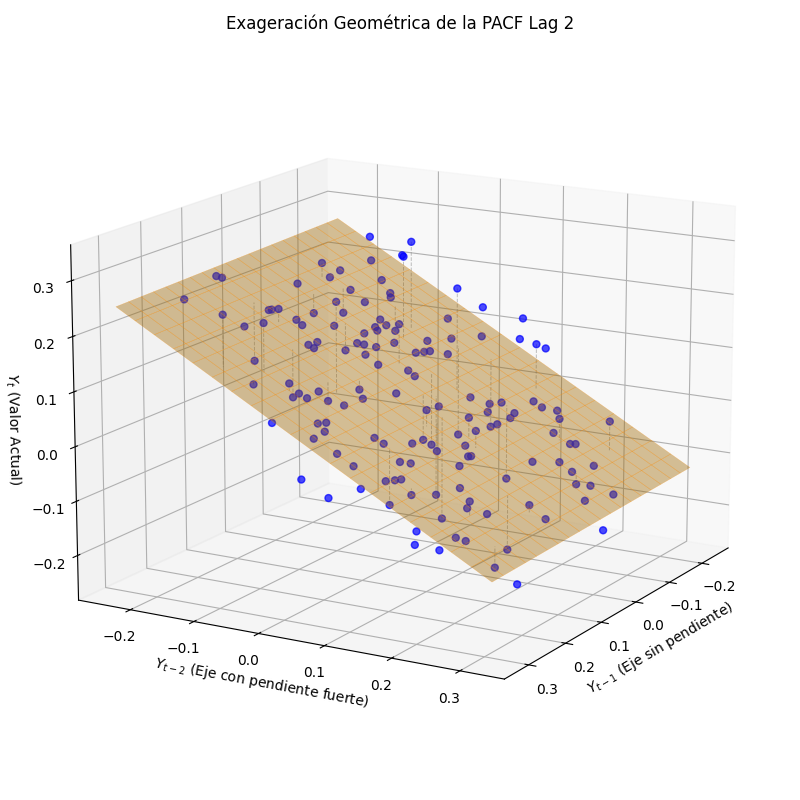

In [3]:
%matplotlib ipympl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Generar el dataset sintético NO ESTACIONARIO (Con Tendencia)
np.random.seed(42)
n_samples = 150
errores = np.random.normal(0, 0.1, n_samples)
serie = np.zeros(n_samples)

serie[0], serie[1] = 0, 0
for t in range(2, n_samples):
    # EXAGERACIÓN: Lag 1 no influye directo (0.0). Lag 2 influye con fuerza (-0.7).
    # Añadimos además un término constante (+0.1) que acumula una TENDENCIA lineal determinista.
    serie[t] = 0.0 * serie[t - 1] - 0.7 * serie[t - 2] + 0.1 + errores[t]

df = pd.DataFrame({"Values": serie})
valores = df["Values"].values

# 2. Matriz de diseño (lag=2)
X, y = [], []
for i in range(2, len(valores)):
    X.append([valores[i - 1], valores[i - 2]])
    y.append(valores[i])
X, y = np.array(X), np.array(y)

# 3. Ajustar el plano con sklearn
modelo = LinearRegression()
modelo.fit(X, y)

phi_1 = modelo.coef_[0]  # Pendiente en dirección t-1 (Debería dar ~ 0)
phi_2 = modelo.coef_[1]  # PACF en lag=2 (Debería dar ~ -0.7)
intercepto = modelo.intercept_

print("--- COEFICIENTES ESTIMADOS (PENDIENTES DEL PLANO) ---")
print(f"Dirección Y_(t-1) [Lag 1]: {phi_1:.4f} (Sin inclinación)")
print(f"Dirección Y_(t-2) [Lag 2]: {phi_2:.4f} (Pendiente fuerte - PACF)")
print(f"Intercepto (Absorbe la tendencia): {intercepto:.4f}\n")

# 4. Configurar el gráfico 3D interactivo
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Grilla para el plano basada en el rango de los datos
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
grilla_x, grilla_y = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))
grilla_z = phi_1 * grilla_x + phi_2 * grilla_y + intercepto

# Dibujar el plano de regresión (Notarás que es un plano "techo de dos aguas" inclinado en un solo eje)
superficie = ax.plot_surface(grilla_x, grilla_y, grilla_z, color='orange', alpha=0.4, edgecolor='darkorange', linewidth=0.3)

# Graficar los puntos reales (Verás cómo trepan en el espacio 3D por la tendencia)
ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=25, label='Datos con Tendencia ($Y_t$)', alpha=0.7)

# Líneas de proyección (residuos) para los primeros 40 puntos
for i in range(40):
    prediccion_z = phi_1 * X[i, 0] + phi_2 * X[i, 1] + intercepto
    ax.plot([X[i, 0], X[i, 0]], [X[i, 1], X[i, 1]], [y[i], prediccion_z], color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

# Configurar etiquetas y vista
ax.set_xlabel('$Y_{t-1}$ (Eje sin pendiente)', fontsize=10)
ax.set_ylabel('$Y_{t-2}$ (Eje con pendiente fuerte)', fontsize=10)
ax.set_zlabel('$Y_t$ (Valor Actual)', fontsize=10)
ax.set_title('Exageración Geométrica de la PACF Lag 2', fontsize=12)

# Ajuste de cámara inicial interactiva
ax.view_init(elev=15, azim=30)
plt.tight_layout()
plt.show()